In [1]:
#  Importación de todas las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Configuración de visualización
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

In [2]:
ticker = "AAPL"

In [3]:
# Definir la ruta a la carpeta donde están tus CSVs de sentimiento
# ¡ADVERTENCIA! Asegúrate de que esta ruta sea correcta para tu configuración de Google Drive.
sentiment_data_path = (
    "../data/01_raw/sentiment/gdelt_apple_avanzado_2020-01-01_a_2026-12-31.csv"
)

In [4]:
df_sentimiento = pd.read_csv(sentiment_data_path)
display(df_sentimiento)

,fecha,volumen_noticias,sentimiento_promedio,puntuacion_positiva,puntuacion_negativa,polaridad_promedio,volatilidad_sentimiento,uso_primera_persona
0,2020-01-01,111,-1.022,2.360,3.381,5.741,3.125,22.523
1,2020-01-02,319,0.109,2.381,2.272,4.653,2.470,22.716
2,2020-01-03,311,-0.434,2.338,2.773,5.111,2.696,23.361
3,2020-01-04,124,-0.275,2.507,2.782,5.289,2.975,21.719
4,2020-01-05,99,0.779,3.425,2.646,6.071,3.125,22.676
...,...,...,...,...,...,...,...,...
2322,2026-05-28,153,0.743,3.097,2.353,5.450,2.893,22.776
2323,2026-05-29,117,-1.202,2.674,3.876,6.550,4.063,22.428
2324,2026-05-30,66,0.983,3.698,2.714,6.412,3.895,22.072
2325,2026-05-31,47,0.635,3.390,2.755,6.146,4.040,22.990


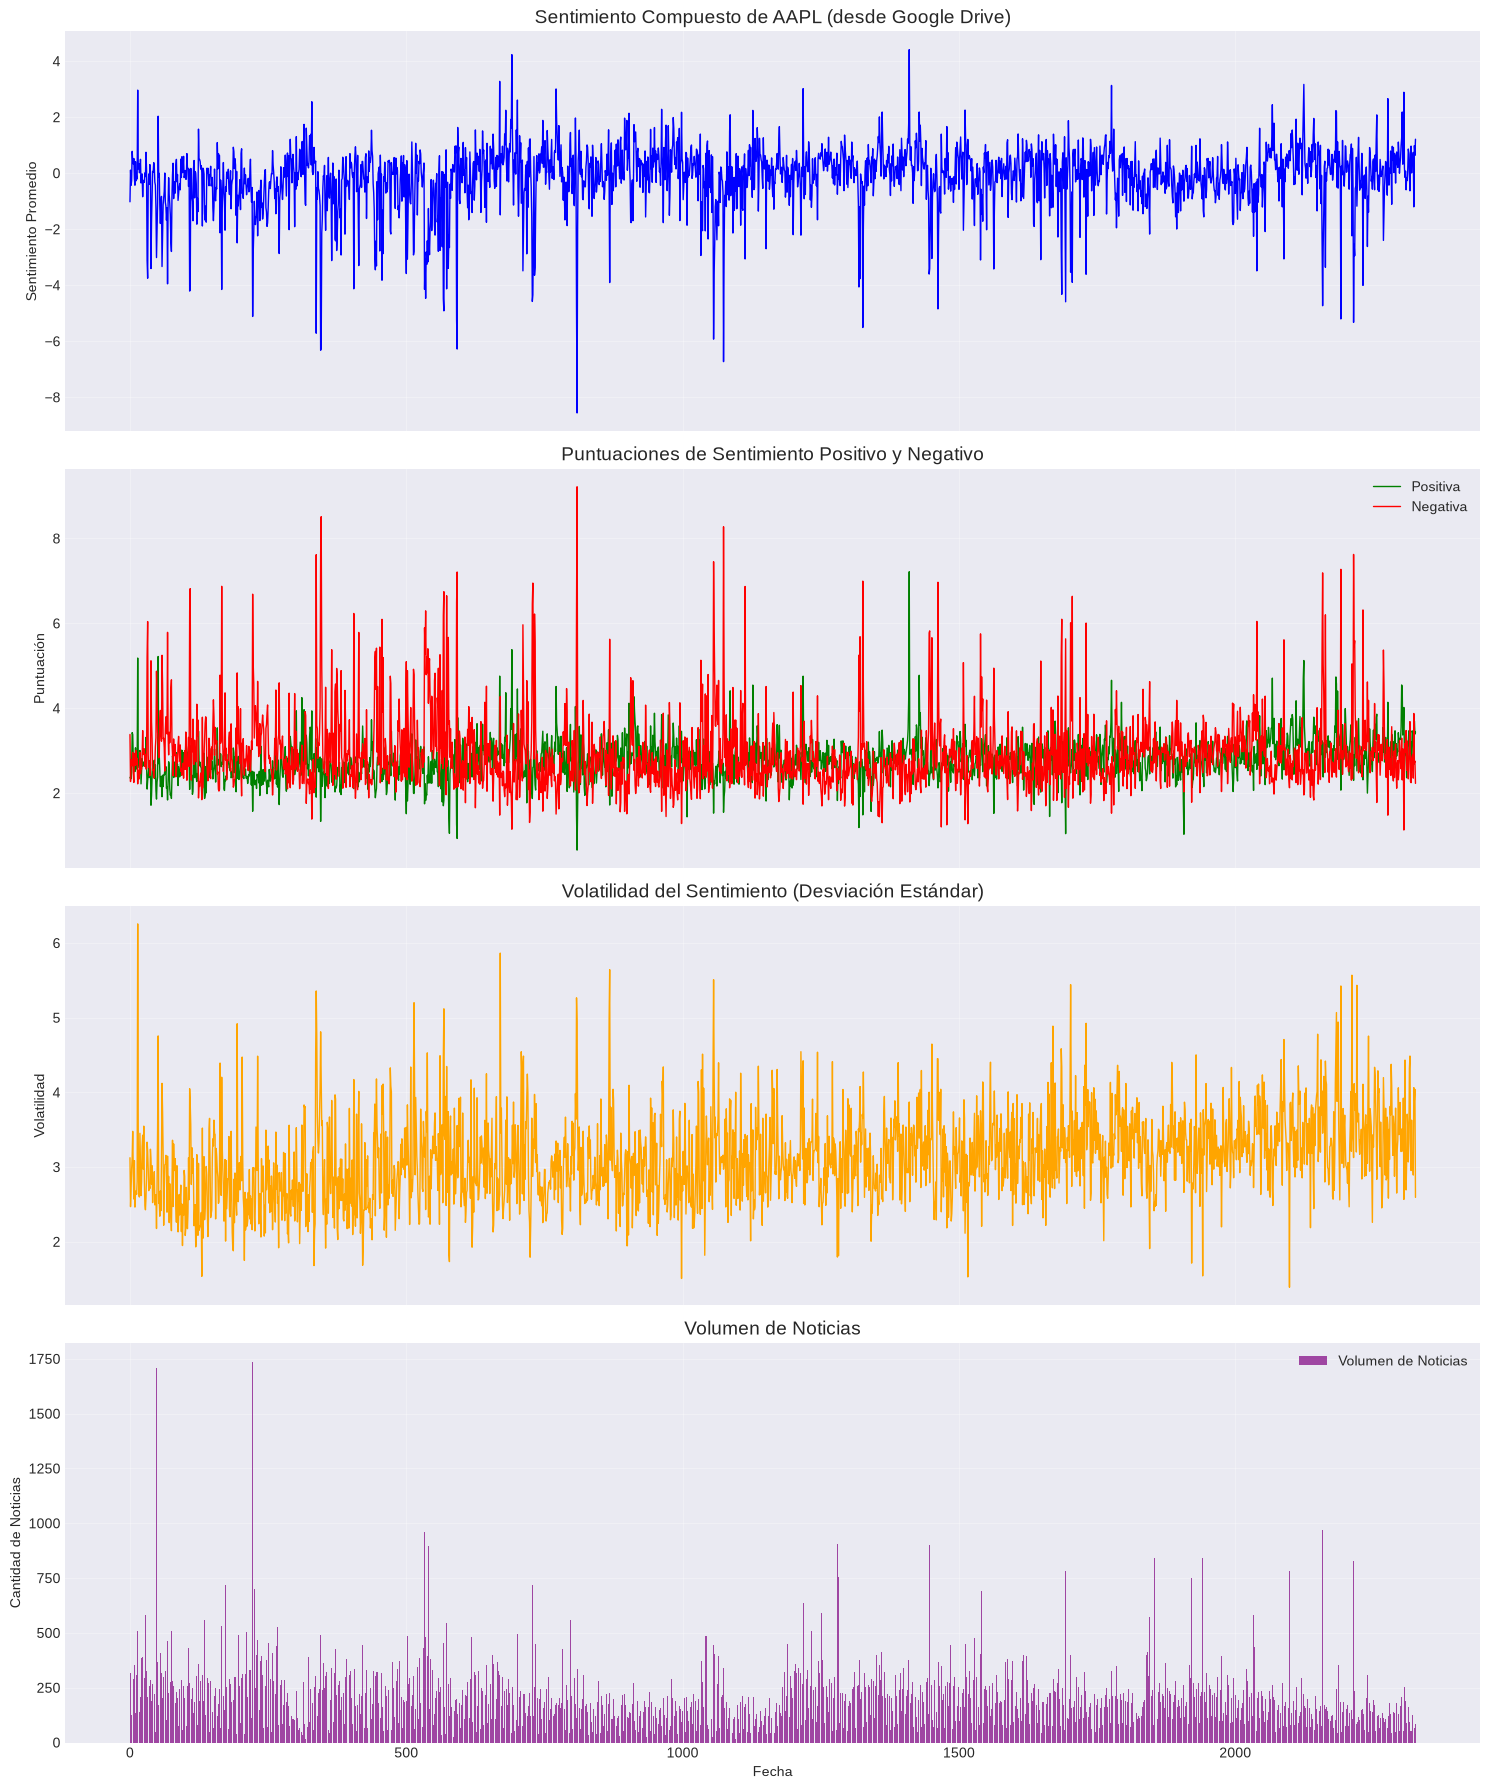

In [5]:
# Visualización de los datos cargados con más métricas
fig, axes = plt.subplots(4, 1, figsize=(15, 18), sharex=True)

# 1. Sentimiento Compuesto
axes[0].plot(
    df_sentimiento.index,
    df_sentimiento["sentimiento_promedio"],
    color="blue",
    linewidth=1,
)
axes[0].set_title(
    f"Sentimiento Compuesto de {ticker.upper()} (desde Google Drive)", fontsize=14
)
axes[0].set_ylabel("Sentimiento Promedio")
axes[0].grid(True, alpha=0.3)

# 2. Puntuaciones Positiva y Negativa
axes[1].plot(
    df_sentimiento.index,
    df_sentimiento["puntuacion_positiva"],
    color="green",
    linewidth=1,
    label="Positiva",
)
axes[1].plot(
    df_sentimiento.index,
    df_sentimiento["puntuacion_negativa"],
    color="red",
    linewidth=1,
    label="Negativa",
)
axes[1].set_title("Puntuaciones de Sentimiento Positivo y Negativo", fontsize=14)
axes[1].set_ylabel("Puntuación")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Volatilidad del Sentimiento
axes[2].plot(
    df_sentimiento.index,
    df_sentimiento["volatilidad_sentimiento"],
    color="orange",
    linewidth=1,
)
axes[2].set_title("Volatilidad del Sentimiento (Desviación Estándar)", fontsize=14)
axes[2].set_ylabel("Volatilidad")
axes[2].grid(True, alpha=0.3)

# 4. Volumen de Noticias
axes[3].bar(
    df_sentimiento.index,
    df_sentimiento["volumen_noticias"],
    color="purple",
    alpha=0.7,
    label="Volumen de Noticias",
)
axes[3].set_title("Volumen de Noticias", fontsize=14)
axes[3].set_xlabel("Fecha")
axes[3].set_ylabel("Cantidad de Noticias")
axes[3].grid(True, alpha=0.3)
axes[3].legend()

plt.tight_layout()
plt.show()

## 1.2 Obtención de datos de VIX

Usaremos Yahoo Finance para la obtención de esta información

In [6]:
stock_data_csv = "../data/03_features/stock/AAPL.csv"
df_stock_data = pd.read_csv(stock_data_csv)

In [7]:
vix_data_csv = "../data/03_features/stock/VIX.csv"
df_vix_data = pd.read_csv(vix_data_csv)

In [8]:
# Celda 3: Descarga y análisis del VIX
# VIX es el índice de volatilidad del mercado (índice del miedo)
print("📈 Descargando datos del VIX...")


# Categorizar niveles de VIX
def categorize_vix(vix_value):
    if vix_value < 20:
        return "Bajo"
    elif vix_value < 30:
        return "Moderado"
    elif vix_value < 40:
        return "Alto"
    else:
        return "Muy Alto"


df_vix_data["VIX_Category"] = df_vix_data["close"].apply(categorize_vix)

display(df_vix_data)

📈 Descargando datos del VIX...


,date,close,high,low,open,volume,VIX_Category
0,2020-01-02,12.470000,13.720000,12.420000,13.460000,0,Bajo
1,2020-01-03,14.020000,16.200001,13.130000,15.010000,0,Bajo
2,2020-01-06,13.850000,16.389999,13.540000,15.450000,0,Bajo
3,2020-01-07,13.790000,14.460000,13.390000,13.840000,0,Bajo
4,2020-01-08,13.450000,15.240000,12.830000,15.160000,0,Bajo
...,...,...,...,...,...,...,...
1626,2026-06-23,19.490000,20.540001,18.610001,19.670000,0,Bajo
1627,2026-06-24,18.629999,20.340000,18.040001,19.129999,0,Bajo
1628,2026-06-25,18.889999,19.950001,17.719999,18.110001,0,Bajo
1629,2026-06-26,18.410000,20.719999,18.200001,19.700001,0,Bajo


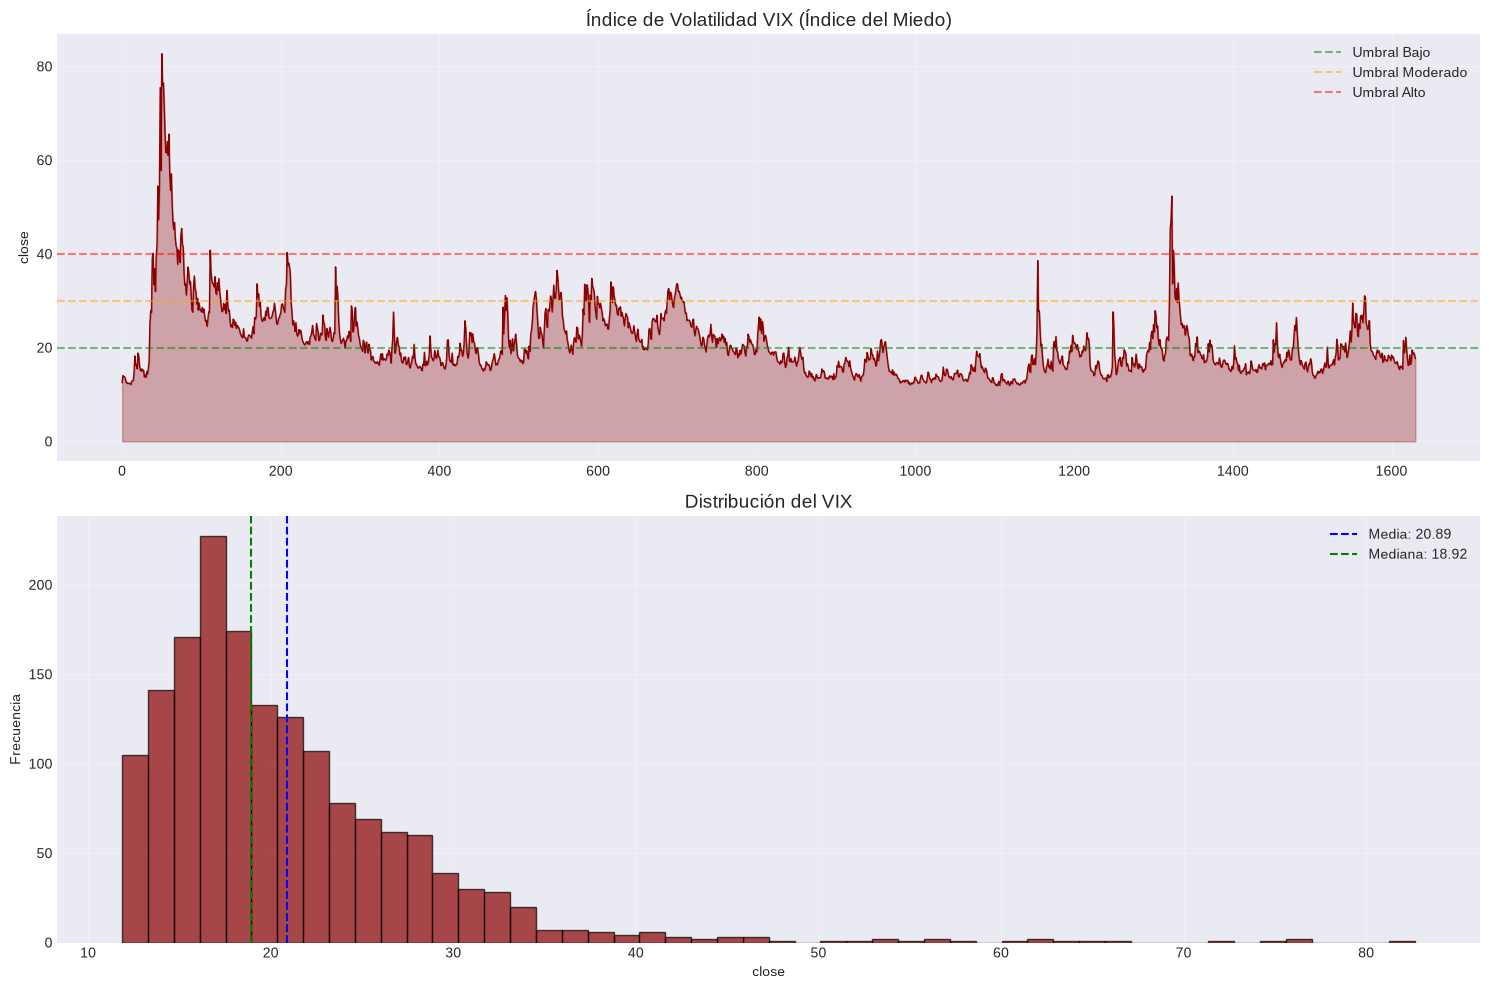


📊 Distribución de Categorías VIX:
Bajo: 926 días (56.8%)
Moderado: 556 días (34.1%)
Alto: 110 días (6.7%)
Muy Alto: 39 días (2.4%)


In [9]:
# Visualización del VIX
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Gráfico 1: Serie temporal del VIX
ax1 = axes[0]
ax1.plot(df_vix_data.index, df_vix_data["close"], color="darkred", linewidth=1)
ax1.axhline(y=20, color="green", linestyle="--", alpha=0.5, label="Umbral Bajo")
ax1.axhline(y=30, color="orange", linestyle="--", alpha=0.5, label="Umbral Moderado")
ax1.axhline(y=40, color="red", linestyle="--", alpha=0.5, label="Umbral Alto")
ax1.fill_between(df_vix_data.index, 0, df_vix_data["close"], alpha=0.3, color="darkred")
ax1.set_title("Índice de Volatilidad VIX (Índice del Miedo)", fontsize=14)
ax1.set_ylabel("close")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfico 2: Distribución del VIX
ax2 = axes[1]
df_vix_data["close"].hist(
    bins=50, ax=ax2, color="darkred", alpha=0.7, edgecolor="black"
)
ax2.axvline(
    x=df_vix_data["close"].mean(),
    color="blue",
    linestyle="--",
    label=f"Media: {df_vix_data['close'].mean():.2f}",
)
ax2.axvline(
    x=df_vix_data["close"].median(),
    color="green",
    linestyle="--",
    label=f"Mediana: {df_vix_data['close'].median():.2f}",
)
ax2.set_title("Distribución del VIX", fontsize=14)
ax2.set_xlabel("close")
ax2.set_ylabel("Frecuencia")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Análisis de categorías
vix_category_counts = df_vix_data["VIX_Category"].value_counts()
print("\n📊 Distribución de Categorías VIX:")
for category, count in vix_category_counts.items():
    percentage = (count / len(df_vix_data)) * 100
    print(f"{category}: {count} días ({percentage:.1f}%)")

## 2. Carga de Datos Históricos y Cálculo de Indicadores Técnicos

## 2.1 Carga de datos históricos

In [10]:
df_stock_data

,date,close,high,low,open,volume,RSI,daily_return,SMA_10,SMA_50,volatilidad_10d,target_direction
0,2020-01-02,72.333900,72.394108,71.091206,71.344077,135480400,NaN,NaN,NaN,NaN,NaN,0
1,2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800,0.000000,-0.009722,NaN,NaN,NaN,1
2,2020-01-06,72.201401,72.239935,70.503539,70.754006,118387200,44.799895,0.007968,NaN,NaN,NaN,0
3,2020-01-07,71.861824,72.466307,71.642666,72.211026,108872000,35.371827,-0.004703,NaN,NaN,NaN,1
4,2020-01-08,73.017838,73.318877,71.565621,71.565621,132079200,62.347218,0.016087,NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1625,2026-06-23,294.299988,301.640015,294.179993,297.540009,52010900,30.408686,-0.009124,294.982001,290.046207,0.016319,0
1626,2026-06-24,293.079987,299.700012,292.940002,295.359985,53081900,32.688418,-0.004145,295.235001,290.728578,0.011207,0
1627,2026-06-25,275.149994,288.799988,273.750000,287.399994,107013700,22.904770,-0.061178,293.592001,291.059743,0.022512,1
1628,2026-06-26,283.779999,285.950012,274.209991,275.000000,261775500,33.482897,0.031365,292.407001,291.411648,0.024755,0



📊 Información del Dataset:
Período: 2020-01-02 a 2026-06-29
Total de días de trading: 1630
Años de datos: 6.5


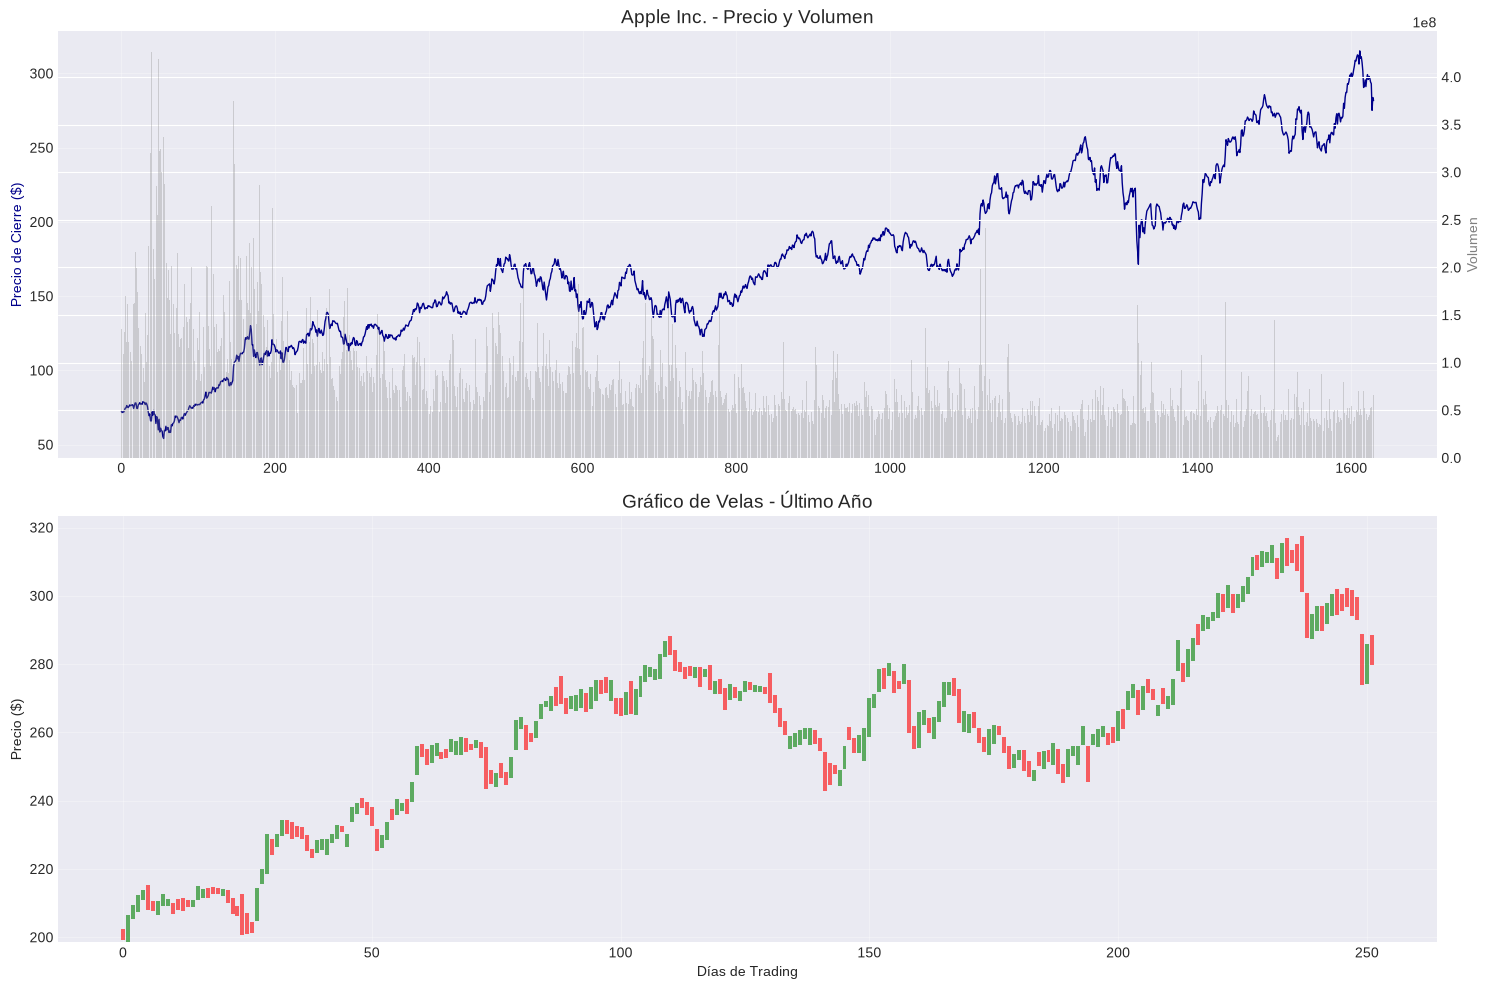

In [11]:
# Información básica
print("\n📊 Información del Dataset:")
print(f"Período: {df_stock_data['date'].iloc[0]} a {df_stock_data['date'].iloc[-1]}")
print(f"Total de días de trading: {len(df_stock_data)}")
print(
    f"Años de datos: {(pd.to_datetime(df_stock_data['date'].iloc[-1]) - pd.to_datetime(df_stock_data['date'].iloc[0])).days / 365:.1f}"
)

# Visualización inicial
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Precio y volumen
ax1 = axes[0]
ax2 = ax1.twinx()
ax1.plot(df_stock_data.index, df_stock_data["close"], color="darkblue", linewidth=1)
ax2.bar(df_stock_data.index, df_stock_data["volume"], alpha=0.3, color="gray")
ax1.set_ylabel("Precio de Cierre ($)", color="darkblue")
ax2.set_ylabel("Volumen", color="gray")
ax1.set_title("Apple Inc. - Precio y Volumen", fontsize=14)
ax1.grid(True, alpha=0.3)

# OHLC con velas japonesas
ax3 = axes[1]
# Simplificamos mostrando solo el último año para mejor visualización
last_year_data = df_stock_data.iloc[-252:]
colors = [
    "g" if close >= open_ else "r"
    for close, open_ in zip(last_year_data["close"], last_year_data["open"])
]
ax3.bar(
    range(len(last_year_data)),
    last_year_data["high"] - last_year_data["low"],
    bottom=last_year_data["low"],
    color=colors,
    alpha=0.6,
)
ax3.set_title("Gráfico de Velas - Último Año", fontsize=14)
ax3.set_ylabel("Precio ($)")
ax3.set_xlabel("Días de Trading")
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
features_path_csv = "../data/03_features/features/AAPL/features.csv"
df_master = pd.read_csv(features_path_csv)

df_master["date"] = pd.to_datetime(df_master["date"])
df_master = df_master.set_index("date")

In [13]:
# Eliminar filas que no tienen datos de cotización (donde 'Close' es NaN)
df_master = df_master.dropna(subset=["close"])

print("DataFrame unificado 'df_master' creado. Primeras 5 filas:")
display(df_master.head())
print(f"Dimensiones de df_master: {df_master.shape}")

DataFrame unificado 'df_master' creado. Primeras 5 filas:


,close,high,low,open,volume,RSI,daily_return,SMA_10,SMA_50,volatilidad_10d,...,quarter,year,day_of_month,week_of_year,month_sin,month_cos,day_sin,day_cos,sentiment_volume_interaction,vix_rsi_interaction
date,,,,,,,,,,,,,,,,,,,,,
2020-03-13,67.102928,67.573668,61.063012,63.945374,370732000,45.068541,0.119808,68.219666,73.733389,0.074268,...,1,2020,13,11,1.0,6.123234e-17,-0.433884,-0.900969,-402244220.0,26.063138
2020-03-16,58.470345,62.542817,57.936841,58.407577,322423600,40.052902,-0.128647,66.853321,73.456118,0.077772,...,1,2020,16,12,1.0,6.123234e-17,0.000000,1.000000,-901173962.0,33.119746
2020-03-17,61.041302,62.187965,57.550605,59.749791,324056000,41.593090,0.043970,65.973166,73.244331,0.079945,...,1,2020,17,12,1.0,6.123234e-17,0.781831,0.623490,-269290536.0,31.573316
2020-03-18,59.547005,60.350879,57.241600,57.881322,300233600,43.998927,-0.024480,64.619617,72.991243,0.077447,...,1,2020,18,12,1.0,6.123234e-17,0.974928,-0.222521,-9607475.2,33.637179
2020-03-19,59.090755,61.036467,58.566910,59.720819,271857200,43.661290,-0.007662,63.457501,72.735822,0.077314,...,1,2020,19,12,1.0,6.123234e-17,0.433884,-0.900969,96509306.0,31.436129


Dimensiones de df_master: (1551, 32)


In [14]:
# Añadir características temporales
df_master["day_of_week"] = df_master.index.dayofweek
df_master["month"] = df_master.index.month
df_master["quarter"] = df_master.index.quarter
df_master["year"] = df_master.index.year
df_master["day_of_month"] = df_master.index.day
df_master["week_of_year"] = df_master.index.isocalendar().week

# Añadir características cíclicas
df_master["month_sin"] = np.sin(2 * np.pi * df_master["month"] / 12)
df_master["month_cos"] = np.cos(2 * np.pi * df_master["month"] / 12)
df_master["day_sin"] = np.sin(2 * np.pi * df_master["day_of_week"] / 7)
df_master["day_cos"] = np.cos(2 * np.pi * df_master["day_of_week"] / 7)

# Crear interacciones entre variables clave
# 'Return_5d' no está en el DataFrame, por lo que se eliminará por ahora.
# Necesitaríamos recalcular los retornos si se quieren usar.
df_master["sentiment_volume_interaction"] = (
    df_master["sentimiento_promedio"] * df_master["volume"]
)
df_master["vix_rsi_interaction"] = df_master["VIX"] * df_master["RSI"] / 100

In [15]:
# Limpiar datos
print("\n🧹 Limpieza de datos:")
print(f"Filas antes de limpieza: {len(df_master)}")
print(f"Columnas totales: {len(df_master.columns)}")

# Eliminar columnas con más del 50% de valores faltantes
missing_threshold = 0.5
missing_pct = df_master.isnull().sum() / len(df_master)
cols_to_drop = missing_pct[missing_pct > missing_threshold].index
df_master = df_master.drop(columns=cols_to_drop)
print(f"Columnas eliminadas por exceso de NaN: {len(cols_to_drop)}")

# Eliminar filas con valores faltantes
df_master = df_master.dropna()
print(f"Filas después de limpieza: {len(df_master)}")


🧹 Limpieza de datos:
Filas antes de limpieza: 1551
Columnas totales: 32
Columnas eliminadas por exceso de NaN: 0
Filas después de limpieza: 1551


## EVIDENCIA

Se muestra una tabla consolidada donde cada fila represente una fecha y las columnas incluyan variables de sentimiento, técnicas y fundamentales.

In [16]:
display(df_master.head(4))
df_master.info()

,close,high,low,open,volume,RSI,daily_return,SMA_10,SMA_50,volatilidad_10d,...,quarter,year,day_of_month,week_of_year,month_sin,month_cos,day_sin,day_cos,sentiment_volume_interaction,vix_rsi_interaction
date,,,,,,,,,,,,,,,,,,,,,
2020-03-13,67.102928,67.573668,61.063012,63.945374,370732000,45.068541,0.119808,68.219666,73.733389,0.074268,...,1,2020,13,11,1.0,6.123234e-17,-0.433884,-0.900969,-402244220.0,26.063138
2020-03-16,58.470345,62.542817,57.936841,58.407577,322423600,40.052902,-0.128647,66.853321,73.456118,0.077772,...,1,2020,16,12,1.0,6.123234e-17,0.000000,1.000000,-901173962.0,33.119746
2020-03-17,61.041302,62.187965,57.550605,59.749791,324056000,41.593090,0.043970,65.973166,73.244331,0.079945,...,1,2020,17,12,1.0,6.123234e-17,0.781831,0.623490,-269290536.0,31.573316
2020-03-18,59.547005,60.350879,57.241600,57.881322,300233600,43.998927,-0.024480,64.619617,72.991243,0.077447,...,1,2020,18,12,1.0,6.123234e-17,0.974928,-0.222521,-9607475.2,33.637179


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1551 entries, 2020-03-13 to 2026-06-01
Data columns (total 32 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   close                         1551 non-null   float64
 1   high                          1551 non-null   float64
 2   low                           1551 non-null   float64
 3   open                          1551 non-null   float64
 4   volume                        1551 non-null   int64  
 5   RSI                           1551 non-null   float64
 6   daily_return                  1551 non-null   float64
 7   SMA_10                        1551 non-null   float64
 8   SMA_50                        1551 non-null   float64
 9   volatilidad_10d               1551 non-null   float64
 10  target_direction              1551 non-null   int64  
 11  VIX                           1551 non-null   float64
 12  fecha                         1551 non-null 

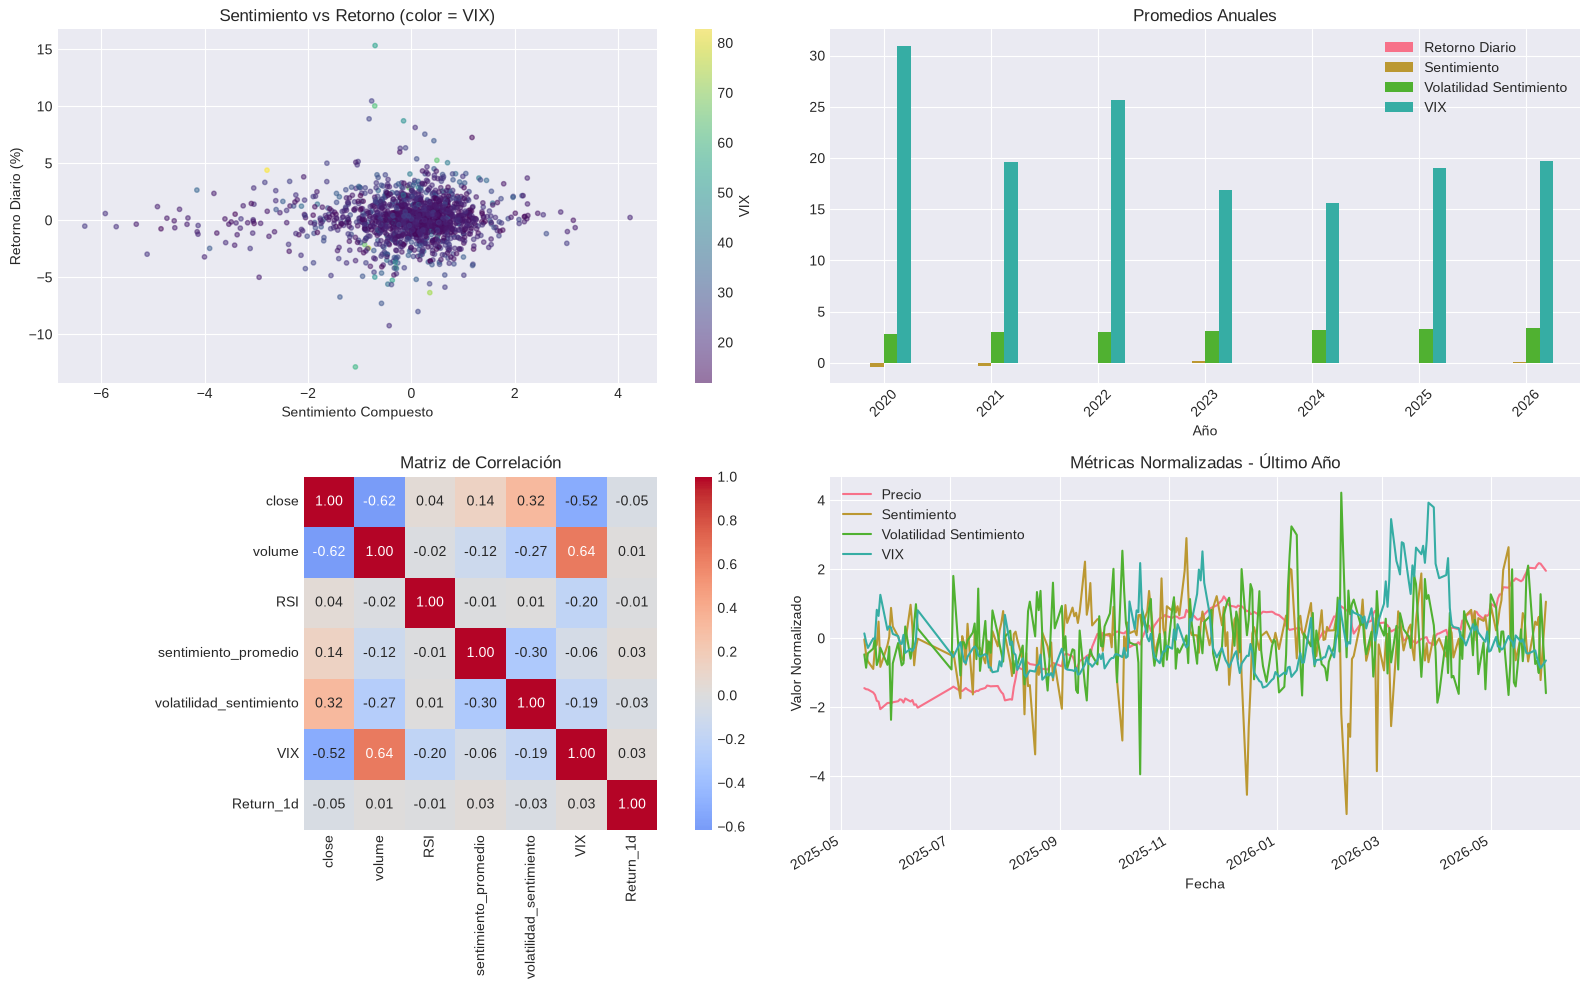


✅ DataFrame maestro creado exitosamente!
Dimensiones finales: (1551, 33)

Primeras columnas disponibles:
  1. close
  2. high
  3. low
  4. open
  5. volume
  6. RSI
  7. daily_return
  8. SMA_10
  9. SMA_50
  10. volatilidad_10d
  11. target_direction
  12. VIX
  13. fecha
  14. volumen_noticias
  15. sentimiento_promedio
  16. puntuacion_positiva
  17. puntuacion_negativa
  18. polaridad_promedio
  19. volatilidad_sentimiento
  20. uso_primera_persona
  ... y 13 columnas más


In [24]:
# Visualización del dataset unificado
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Recalcular Return_1d si no existe para la visualización
if "Return_1d" not in df_master.columns:
    df_master["Return_1d"] = (
        df_master["close"].pct_change().shift(-1)
    )  # calculate 1-day return

# 1. Correlación entre sentimiento y precio
ax1 = axes[0, 0]
scatter = ax1.scatter(
    df_master["sentimiento_promedio"],
    df_master["Return_1d"] * 100,
    c=df_master["VIX"],
    cmap="viridis",
    alpha=0.5,
    s=10,
)
ax1.set_xlabel("Sentimiento Compuesto")
ax1.set_ylabel("Retorno Diario (%)")
ax1.set_title("Sentimiento vs Retorno (color = VIX)")
plt.colorbar(scatter, ax=ax1, label="VIX")

# 2. Distribución de características por año
ax2 = axes[0, 1]
yearly_stats = df_master.groupby("year")[
    ["Return_1d", "sentimiento_promedio", "volatilidad_sentimiento", "VIX"]
].mean()
yearly_stats.plot(kind="bar", ax=ax2)
ax2.set_title("Promedios Anuales")
ax2.set_xlabel("Año")
ax2.legend(["Retorno Diario", "Sentimiento", "Volatilidad Sentimiento", "VIX"])
ax2.tick_params(axis="x", rotation=45)

# 3. Heatmap de correlaciones top
ax3 = axes[1, 0]
# Las características BB_Upper, BB_Lower, Stoch_K, Williams_R no están en stock_data
key_features = [
    "close",
    "volume",
    "RSI",
    "MACD",
    "sentimiento_promedio",
    "volatilidad_sentimiento",
    "VIX",
    "Return_1d",
]  # Removed 'ROE', as fundamental_metrics is not used for now
available_features = [f for f in key_features if f in df_master.columns]
corr_matrix = df_master[available_features].corr()
sns.heatmap(
    corr_matrix, annot=True, cmap="coolwarm", center=0, ax=ax3, fmt=".2f", square=True
)
ax3.set_title("Matriz de Correlación")

# 4. Series temporales de métricas clave
ax4 = axes[1, 1]
normalized_data = df_master[
    ["close", "sentimiento_promedio", "volatilidad_sentimiento", "VIX"]
].iloc[-252:]
normalized_data = (normalized_data - normalized_data.mean()) / normalized_data.std()
normalized_data.plot(ax=ax4)
ax4.set_title("Métricas Normalizadas - Último Año")
ax4.set_xlabel("Fecha")
ax4.set_ylabel("Valor Normalizado")
ax4.legend(["Precio", "Sentimiento", "Volatilidad Sentimiento", "VIX"])

plt.tight_layout()
plt.show()

print("\n✅ DataFrame maestro creado exitosamente!")
print(f"Dimensiones finales: {df_master.shape}")
print("\nPrimeras columnas disponibles:")
for i, col in enumerate(df_master.columns[:20]):
    print(f"  {i + 1}. {col}")
print(f"  ... y {len(df_master.columns) - 20} columnas más")

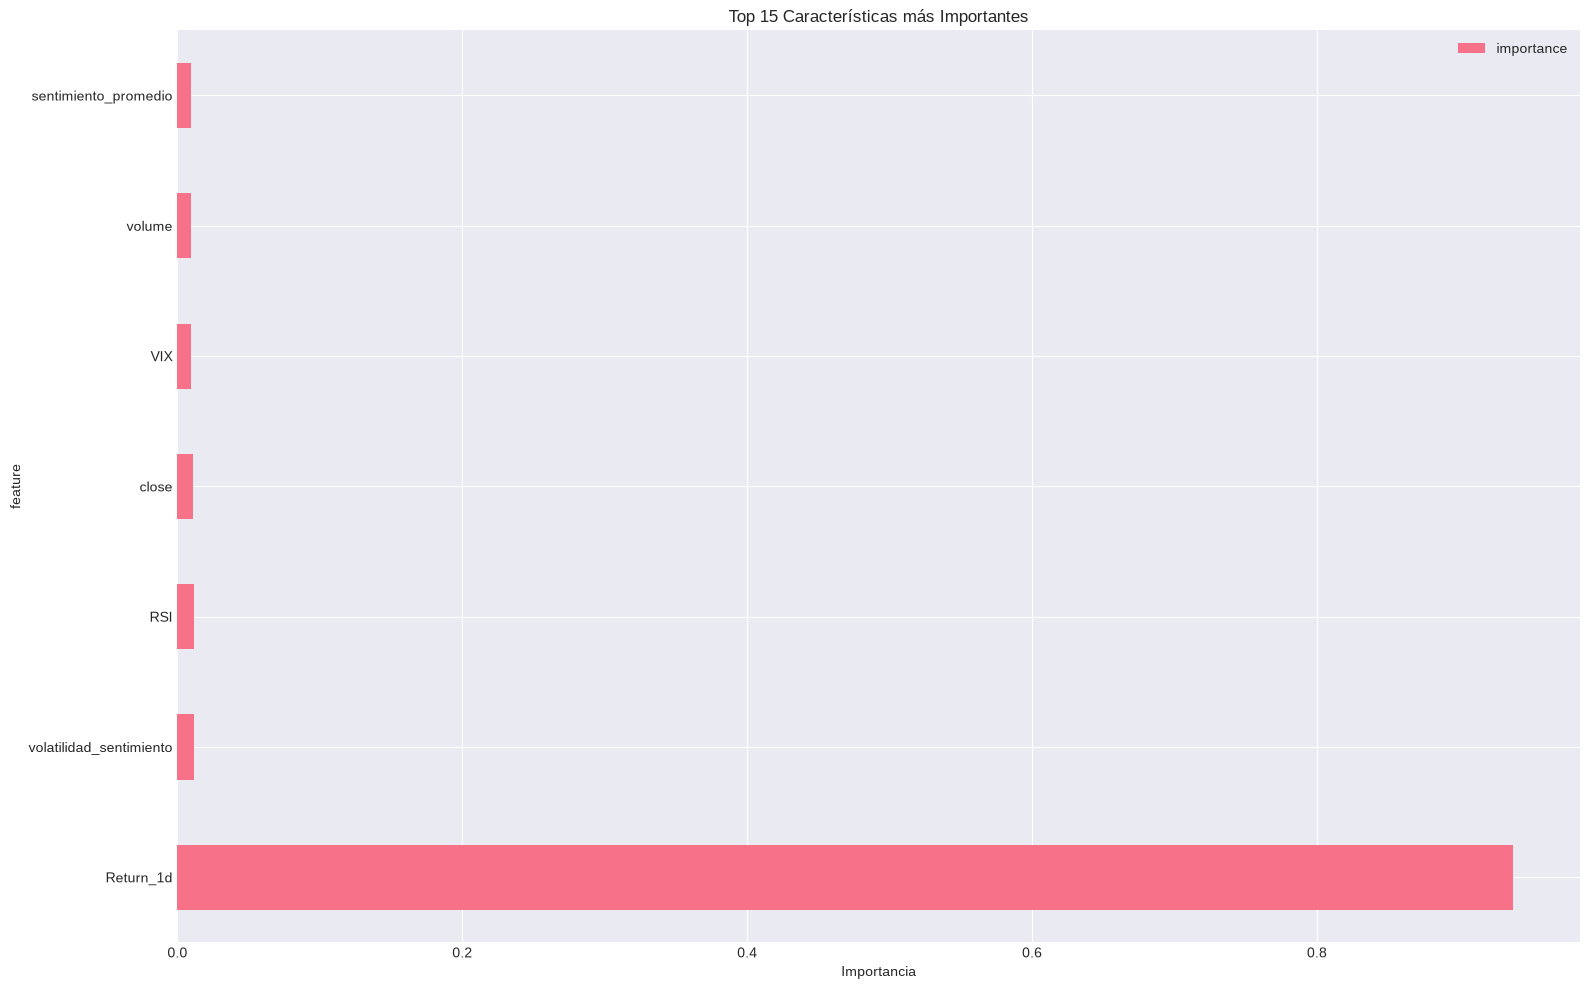

In [25]:
from sklearn.ensemble import RandomForestClassifier

# Preparar X e y
X = df_master[available_features].dropna()
y = df_master.loc[X.index, "target_direction"]

# Eliminar la última fila (no tiene target)
X = X[:-1]
y = y[:-1]

# Análisis de características
fig, axes = plt.subplots(1, 1, figsize=(16, 10))

# 1. Importancia de características usando Random Forest
ax1 = axes
rf_temp = RandomForestClassifier(n_estimators=100, random_state=42)
rf_temp.fit(X, y)
feature_importance = (
    pd.DataFrame(
        {
            "feature": X.columns,  # Usar X.columns directamente ya que available_features son las de X
            "importance": rf_temp.feature_importances_,
        }
    )
    .sort_values("importance", ascending=False)
    .head(15)
)

feature_importance.plot(x="feature", y="importance", kind="barh", ax=ax1)
ax1.set_title("Top 15 Características más Importantes")
ax1.set_xlabel("Importancia")

plt.tight_layout()
plt.show()

## 5. Desarrollo del Modelo Predictivo

In [ ]:
# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
)
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

In [ ]:
print("🎯 Preparando datos para el modelo predictivo...")

# Crear variable objetivo
df_master["target"] = (df_master["Close"].shift(-1) > df_master["Close"]).astype(int)

# Seleccionar características relevantes (actualizado para reflejar las columnas disponibles)
feature_columns = [
    # Técnicos
    "Close",
    "High",
    "Low",
    "Open",
    "Volume",
    "RSI",
    "EMA",
    "EMA_Short",
    "EMA_Long",
    "MACD",
    "Signal_Line",
    "MACD_Histogram",
    # Sentimiento (usando los nombres de df_sentimiento)
    "sentimiento_promedio",
    "volatilidad_sentimiento",
    # Mercado
    "VIX",
    # Temporales
    "day_of_week",
    "month",
    "quarter",
    "year",
    "day_of_month",
    "week_of_year",
    "month_sin",
    "month_cos",
    "day_sin",
    "day_cos",
    # Interacciones
    "sentiment_volume_interaction",
    "vix_rsi_interaction",
]

# Filtrar solo las columnas disponibles
# Aunque la lista feature_columns ya es precisa, mantenemos esta línea para robustez
available_features = [col for col in feature_columns if col in df_master.columns]
print(f"\n📊 Características disponibles: {len(available_features)}")

# Preparar X e y
X = df_master[available_features].dropna()
y = df_master.loc[X.index, "target"]

# Eliminar la última fila (no tiene target)
X = X[:-1]
y = y[:-1]

print(f"Forma de X: {X.shape}")
print(f"Forma de y: {y.shape}")
print(f"Distribución de clases: {y.value_counts().to_dict()}")
print(f"Balance de clases: {y.mean():.2%} positivas")

# Análisis de características
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Importancia de características usando Random Forest
ax1 = axes[0, 0]
rf_temp = RandomForestClassifier(n_estimators=100, random_state=42)
rf_temp.fit(X, y)
feature_importance = (
    pd.DataFrame(
        {
            "feature": X.columns,  # Usar X.columns directamente ya que available_features son las de X
            "importance": rf_temp.feature_importances_,
        }
    )
    .sort_values("importance", ascending=False)
    .head(15)
)

feature_importance.plot(x="feature", y="importance", kind="barh", ax=ax1)
ax1.set_title("Top 15 Características más Importantes")
ax1.set_xlabel("Importancia")

# 2. Distribución de la variable objetivo por período
ax2 = axes[0, 1]
target_by_year = df_master.groupby("year")["target"].mean()
target_by_year.plot(kind="bar", ax=ax2, color="skyblue")
ax2.set_title("Proporción de Días Alcistas por Año")
ax2.set_ylabel("Proporción")
ax2.axhline(y=0.5, color="red", linestyle="--", alpha=0.5)
ax2.tick_params(axis="x", rotation=45)

# 3. Análisis de características por clase
ax3 = axes[1, 0]
top_features = feature_importance.head(6)["feature"].values
for i, feature in enumerate(top_features):
    if feature in X.columns:
        X[feature].hist(bins=30, alpha=0.5, ax=ax3, label=f"{feature}", density=True)
ax3.set_title("Distribución de Top Características")
ax3.set_xlabel("Valor")
ax3.set_ylabel("Densidad")
ax3.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

# 4. Correlación con el target
ax4 = axes[1, 1]
target_corr = X.corrwith(y).sort_values(ascending=False)
top_corr_features = pd.concat([target_corr.head(10), target_corr.tail(10)])
top_corr_features.plot(kind="barh", ax=ax4)
ax4.set_title("Correlación con la Variable Objetivo")
ax4.set_xlabel("Correlación")
ax4.axvline(x=0, color="black", linestyle="-", alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# Celda 10: Implementación de múltiples modelos con validación temporal
# This cell was modified to ensure X and y are defined before execution.
print("🤖 Implementando modelos de Machine Learning...")

# División temporal de datos (80% train, 20% test)
split_index = int(len(X) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print("\n📊 División de datos:")
print(
    f"Entrenamiento: {len(X_train)} muestras ({len(X_train) / len(X) * 100:.1f}%)者に"
)
print(f"Prueba: {len(X_test)} muestras ({len(X_test) / len(X) * 100:.1f}%)者に")
print(f"Balance en train: {y_train.mean():.2%} positivas")
print(f"Balance en test: {y_test.mean():.2%} positivas")

# Normalización de datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Aplicar SMOTE para balancear clases
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print("\n🔄 Después de SMOTE:")
print(f"Muestras de entrenamiento: {len(X_train_balanced)}")
print(f"Balance: {y_train_balanced.mean():.2%} positivas")

# Diccionario para almacenar resultados
results = {}

# 1. Random Forest
print("\n1️⃣ Entrenando Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train_balanced, y_train_balanced)
rf_pred = rf_model.predict(X_test_scaled)
rf_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

results["Random Forest"] = {
    "model": rf_model,
    "predictions": rf_pred,
    "probabilities": rf_pred_proba,
    "accuracy": accuracy_score(y_test, rf_pred),
    "f1_score": f1_score(y_test, rf_pred),
}

# 2. XGBoost
print("2️⃣ Entrenando XGBoost...")
import xgboost as xgb  # noqa: E402

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.01,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss",
)
xgb_model.fit(X_train_balanced, y_train_balanced)
xgb_pred = xgb_model.predict(X_test_scaled)
xgb_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

results["XGBoost"] = {
    "model": xgb_model,
    "predictions": xgb_pred,
    "probabilities": xgb_pred_proba,
    "accuracy": accuracy_score(y_test, xgb_pred),
    "f1_score": f1_score(y_test, xgb_pred),
}

# 3. LSTM mejorado
print("3️⃣ Entrenando LSTM mejorado...")

# Preparar datos para LSTM
sequence_length = 5  # Adjusted sequence length
X_train_seq, y_train_seq = [], []
for i in range(sequence_length, len(X_train_scaled)):
    X_train_seq.append(X_train_scaled[i - sequence_length : i])
    y_train_seq.append(y_train.iloc[i])

X_test_seq, y_test_seq = [], []
for i in range(sequence_length, len(X_test_scaled)):
    X_test_seq.append(X_test_scaled[i - sequence_length : i])
    y_test_seq.append(y_test.iloc[i])

X_train_seq = np.array(X_train_seq)
X_test_seq = np.array(X_test_seq)
y_train_seq = np.array(y_train_seq)
y_test_seq = np.array(y_test_seq)

# Arquitectura LSTM mejorada
lstm_model = Sequential(
    [
        LSTM(
            128, return_sequences=True, input_shape=(sequence_length, X_train.shape[1])
        ),
        Dropout(0.3),
        BatchNormalization(),
        LSTM(64, return_sequences=True),
        Dropout(0.3),
        BatchNormalization(),
        LSTM(32),
        Dropout(0.3),
        BatchNormalization(),
        Dense(16, activation="relu"),
        Dropout(0.2),
        Dense(1, activation="sigmoid"),
    ]
)

# Compilar con optimizador personalizado
optimizer = Adam(learning_rate=0.001)
lstm_model.compile(
    optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"]
)

# Callbacks
early_stopping = EarlyStopping(
    monitor="val_loss", patience=15, restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=5, min_lr=0.00001
)

# Entrenar
history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=0,
)

# Predicciones LSTM
lstm_pred_proba = lstm_model.predict(X_test_seq)
lstm_pred = (lstm_pred_proba > 0.5).astype(int).flatten()

results["LSTM"] = {
    "model": lstm_model,
    "predictions": lstm_pred,
    "probabilities": lstm_pred_proba.flatten(),
    "accuracy": accuracy_score(y_test_seq, lstm_pred),
    "f1_score": f1_score(y_test_seq, lstm_pred),
}

# Visualización de resultados
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Matrices de confusión
for idx, (model_name, model_results) in enumerate(results.items()):
    ax = axes[0, idx]

    # Ajustar para LSTM que tiene diferentes longitudes
    if model_name == "LSTM":
        cm = confusion_matrix(y_test_seq, model_results["predictions"])
    else:
        cm = confusion_matrix(y_test, model_results["predictions"])

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(f"{model_name}\nAccuracy: {model_results['accuracy']:.3f}")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")

# Curvas de aprendizaje LSTM
ax = axes[1, 0]
ax.plot(history.history["accuracy"], label="Train")
ax.plot(history.history["val_accuracy"], label="Validation")
ax.set_title("LSTM - Accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.legend()

ax = axes[1, 1]
ax.plot(history.history["loss"], label="Train")
ax.plot(history.history["val_loss"], label="Validation")
ax.set_title("LSTM - Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()

# Comparación de modelos
ax = axes[1, 2]
model_comparison = pd.DataFrame(
    {
        "Model": list(results.keys()),
        "Accuracy": [results[m]["accuracy"] for m in results.keys()],
        "F1-Score": [results[m]["f1_score"] for m in results.keys()],
    }
)
model_comparison.set_index("Model").plot(kind="bar", ax=ax)
ax.set_title("Comparación de Modelos")
ax.set_ylabel("Score")
ax.tick_params(axis="x", rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Obtención del mejor modelo utilizando max con una clave personalizada
best_model_name, best_model_results = max(
    results.items(), key=lambda item: (item[1]["accuracy"], item[1]["f1_score"])
)

best_model = best_model_results["model"]
best_predictions = best_model_results["predictions"]
best_probabilities = best_model_results["probabilities"]
highest_accuracy = best_model_results["accuracy"]
highest_f1_score = best_model_results["f1_score"]

print(f"El modelo con mejores métricas es {best_model_name}")

In [ ]:
# Celda 11: Análisis de errores y mejoras
print("🔍 Análisis detallado de errores y características...")

# Análisis de errores
errors = best_predictions != y_test
error_indices = y_test.index[errors]

# Crear DataFrame de análisis
error_analysis = pd.DataFrame(
    {
        "Date": X_test.index,
        "True_Label": y_test.values,
        "Prediction": best_predictions,
        "Probability": best_probabilities,
        "Error": errors,
        "Confidence": np.abs(best_probabilities - 0.5),
    }
)

# Añadir características para análisis
for feature in ["RSI", "sentimiento_promedio", "VIX", "Volume", "Return_1d"]:
    if feature in X_test.columns:
        error_analysis[feature] = X_test[feature].values

# Visualización del análisis de errores
fig, axes = plt.subplots(3, 2, figsize=(16, 15))

# 1. Distribución de probabilidades por clase
ax1 = axes[0, 0]
error_analysis[error_analysis["True_Label"] == 0]["Probability"].hist(
    bins=30, alpha=0.5, label="Clase 0 (Bajista)", ax=ax1, color="red"
)
error_analysis[error_analysis["True_Label"] == 1]["Probability"].hist(
    bins=30, alpha=0.5, label="Clase 1 (Alcista)", ax=ax1, color="green"
)
ax1.axvline(x=0.5, color="black", linestyle="--")
ax1.set_title("Distribución de Probabilidades por Clase Real")
ax1.set_xlabel("Probabilidad Predicha")
ax1.legend()

# 2. Errores por nivel de confianza
ax2 = axes[0, 1]
confidence_bins = pd.cut(error_analysis["Confidence"], bins=10)
error_by_confidence = error_analysis.groupby(confidence_bins)["Error"].mean()
error_by_confidence.plot(kind="bar", ax=ax2)
ax2.set_title("Tasa de Error por Nivel de Confianza")
ax2.set_xlabel("Confianza (distancia desde 0.5)")
ax2.set_ylabel("Tasa de Error")
ax2.tick_params(axis="x", rotation=45)

# 3. Análisis temporal de errores
ax3 = axes[1, 0]
monthly_errors = (
    error_analysis.set_index("Date").resample("M")["Error"].agg(["sum", "count"])
)
monthly_errors["error_rate"] = monthly_errors["sum"] / monthly_errors["count"]
monthly_errors["error_rate"].plot(ax=ax3, marker="o")
ax3.set_title("Tasa de Error Mensual")
ax3.set_ylabel("Tasa de Error")
ax3.grid(True, alpha=0.3)

# 4. Características de casos mal clasificados
ax4 = axes[1, 1]
feature_comparison = pd.DataFrame(
    {"Correctos": X_test[~errors].mean(), "Errores": X_test[errors].mean()}
)
top_diff_features = (
    (feature_comparison["Errores"] - feature_comparison["Correctos"])
    .abs()
    .sort_values(ascending=False)
    .head(10)
)
top_diff_features.plot(kind="barh", ax=ax4)
ax4.set_title("Características con Mayor Diferencia entre Aciertos y Errores")
ax4.set_xlabel("Diferencia Absoluta")

# 5. Calibración del modelo
ax5 = axes[2, 0]
from sklearn.calibration import calibration_curve  # noqa: E402

fraction_of_positives, mean_predicted_value = calibration_curve(
    y_test, best_probabilities, n_bins=10
)
ax5.plot(mean_predicted_value, fraction_of_positives, marker="o", label="Random Forest")
ax5.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectamente Calibrado")
ax5.set_title("Curva de Calibración")
ax5.set_xlabel("Probabilidad Media Predicha")
ax5.set_ylabel("Fracción de Positivos")
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. Feature Engineering adicional sugerido
ax6 = axes[2, 1]
# Calcular nuevas características potenciales
X_test_enhanced = X_test.copy()
X_test_enhanced["RSI_Signal"] = (X_test["RSI"] < 30).astype(int) - (
    X_test["RSI"] > 70
).astype(int)
X_test_enhanced["Sentiment_Momentum"] = (
    X_test["sentimiento_promedio"].rolling(5, min_periods=1).mean()
)
X_test_enhanced["Volume_Spike"] = (
    X_test["Volume"] > X_test["Volume"].rolling(20, min_periods=1).mean() * 1.5
).astype(int)

# Evaluar el potencial de nuevas características
new_features_corr = pd.DataFrame(
    {
        "RSI_Signal": X_test_enhanced["RSI_Signal"],
        "Sentiment_Momentum": X_test_enhanced["Sentiment_Momentum"],
        "Volume_Spike": X_test_enhanced["Volume_Spike"],
    }
).corrwith(y_test)

new_features_corr.plot(kind="bar", ax=ax6)
ax6.set_title("Correlación de Nuevas Características Sugeridas")
ax6.set_ylabel("Correlación con Target")
ax6.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# Resumen de insights
print("\n🎯 INSIGHTS CLAVE DEL ANÁLISIS:")
print("=" * 60)

# Casos más difíciles
high_confidence_errors = error_analysis[
    (error_analysis["Error"]) & (error_analysis["Confidence"] > 0.3)
]
print(f"\n1. Errores con alta confianza: {len(high_confidence_errors)} casos")
print(
    f"   - Representan el {len(high_confidence_errors) / len(error_analysis) * 100:.1f}% del total"
)

# Patrones temporales
print("\n2. Patrones temporales:")
worst_month = monthly_errors["error_rate"].idxmax()
best_month = monthly_errors["error_rate"].idxmin()
print(
    f"   - Peor mes: {worst_month.strftime('%Y-%m')} (error: {monthly_errors.loc[worst_month, 'error_rate']:.1%})"
)
print(
    f"   - Mejor mes: {best_month.strftime('%Y-%m')} (error: {monthly_errors.loc[best_month, 'error_rate']:.1%})"
)

# Características problemáticas
print("\n3. Características más diferentes en errores:")
for feat, diff in top_diff_features.head(5).items():
    print(f"   - {feat}: diferencia de {diff:.3f}")

# Sugerencias de mejora
print("\n4. Sugerencias de mejora:")
print("   - Implementar ensemble de modelos para reducir varianza")
print("   - Añadir características de microestructura del mercado")
print("   - Considerar régimen de mercado (bull/bear/lateral)")
print("   - Implementar ventanas adaptativas según volatilidad")
print("   - Incluir datos de opciones para capturar expectativas del mercado")

In [ ]:
import pandas as pd
import numpy as np


def run_trading_simulation(
    close_prices: pd.Series,
    predictions: np.ndarray,
    probabilities: np.ndarray,
    actual_direction: pd.Series,
    initial_capital: float = 100000,
    transaction_cost: float = 0.001,
    confidence_threshold: float = 0.6,
):
    """
    Runs a trading simulation based on model predictions and calculates performance metrics.

    Args:
        close_prices (pd.Series): Series of close prices for the test period.
        predictions (np.ndarray): Binary predictions (0 or 1) from the model.
        probabilities (np.ndarray): Predicted probabilities from the model.
        actual_direction (pd.Series): Actual target values (0 or 1) for the test period.
        initial_capital (float): Starting capital for the simulation.
        transaction_cost (float): Cost per transaction as a percentage (e.g., 0.001 for 0.1%).
        confidence_threshold (float): Probability threshold to generate a signal.
                                      If prob > threshold, signal = 1.
                                      If prob < (1 - threshold), signal = -1.

    Returns:
        dict: A dictionary containing simulation results (total return, Sharpe ratio, max drawdown, etc.).
        pd.DataFrame: The trading_sim DataFrame with all calculated values.
    """
    # Ensure close_prices, predictions, probabilities and actual_direction have compatible lengths
    if not (
        len(close_prices)
        == len(predictions)
        == len(probabilities)
        == len(actual_direction)
    ):
        raise ValueError(
            "Lengths of close_prices, predictions, probabilities, and actual_direction must match."
        )

    # Create DataFrame of simulation
    trading_sim = pd.DataFrame(
        {
            "Price": close_prices.values,
            "Prediction": predictions,
            "Probability": probabilities,
            "Actual_Direction": actual_direction.values,
        },
        index=close_prices.index,
    )

    # Generate signals of trading
    trading_sim["Signal"] = 0
    # Positive signal (buy) if probability of upward movement is high
    trading_sim.loc[trading_sim["Probability"] > confidence_threshold, "Signal"] = 1
    # Negative signal (sell/short) if probability of downward movement is high
    trading_sim.loc[
        trading_sim["Probability"] < (1 - confidence_threshold), "Signal"
    ] = -1

    # Calculate retornos
    trading_sim["Return"] = trading_sim["Price"].pct_change()
    trading_sim["Strategy_Return"] = (
        trading_sim["Signal"].shift(1) * trading_sim["Return"]
    )

    # Apply transaction costs (only when a position changes)
    trading_sim["Strategy_Return"] -= (
        transaction_cost * trading_sim["Signal"].diff().abs()
    )

    # Fill NaN from initial pct_change and shift (first row)
    trading_sim["Strategy_Return"].fillna(0, inplace=True)
    trading_sim["Return"].fillna(0, inplace=True)  # For Buy & Hold

    # Calculate equity curves
    trading_sim["Buy_Hold_Equity"] = (
        initial_capital * (1 + trading_sim["Return"]).cumprod()
    )
    trading_sim["Strategy_Equity"] = (
        initial_capital * (1 + trading_sim["Strategy_Return"]).cumprod()
    )

    # Handle cases where cumprod might result in all NaNs if there are no valid returns
    if trading_sim["Buy_Hold_Equity"].isnull().all():
        trading_sim["Buy_Hold_Equity"] = initial_capital
    if trading_sim["Strategy_Equity"].isnull().all():
        trading_sim["Strategy_Equity"] = initial_capital

    # Métricas de rendimiento
    total_return_bh = (
        (trading_sim["Buy_Hold_Equity"].iloc[-1] / initial_capital - 1)
        if not trading_sim["Buy_Hold_Equity"].empty
        else 0
    )
    total_return_strategy = (
        (trading_sim["Strategy_Equity"].iloc[-1] / initial_capital - 1)
        if not trading_sim["Strategy_Equity"].empty
        else 0
    )

    # Sharpe Ratio calculation requires non-zero standard deviation
    sharpe_bh = (
        np.sqrt(252) * trading_sim["Return"].mean() / trading_sim["Return"].std()
        if trading_sim["Return"].std() != 0
        else 0
    )
    sharpe_strategy = (
        np.sqrt(252)
        * trading_sim["Strategy_Return"].mean()
        / trading_sim["Strategy_Return"].std()
        if trading_sim["Strategy_Return"].std() != 0
        else 0
    )

    # Max Drawdown
    dd_bh = (
        (
            trading_sim["Buy_Hold_Equity"]
            / trading_sim["Buy_Hold_Equity"].expanding().max()
            - 1
        )
        if not trading_sim["Buy_Hold_Equity"].empty
        else pd.Series([0])
    )
    dd_strategy = (
        (
            trading_sim["Strategy_Equity"]
            / trading_sim["Strategy_Equity"].expanding().max()
            - 1
        )
        if not trading_sim["Strategy_Equity"].empty
        else pd.Series([0])
    )
    max_drawdown_bh = dd_bh.min() * 100 if not dd_bh.empty else 0
    max_drawdown_strategy = dd_strategy.min() * 100 if not dd_strategy.empty else 0

    num_operations = trading_sim["Signal"].diff().abs().sum()

    return {
        "total_return_bh": total_return_bh,
        "total_return_strategy": total_return_strategy,
        "sharpe_bh": sharpe_bh,
        "sharpe_strategy": sharpe_strategy,
        "max_drawdown_bh": max_drawdown_bh,
        "max_drawdown_strategy": max_drawdown_strategy,
        "num_operations": num_operations,
    }, trading_sim


print("💰 Simulación de estrategia de trading basada en el modelo...")

# Parámetros de la simulación
initial_capital = 100000
transaction_cost = 0.001  # 0.1% por transacción
confidence_threshold = 0.6  # Solo operar con alta confianza

simulation_results = {}
best_sim_model_name = ""
highest_sim_return = -np.inf  # Initialize with negative infinity for comparison

# Loop through each model and run the simulation
for model_name, model_data in results.items():
    if model_name == "LSTM":
        # For LSTM, predictions and probabilities are based on y_test_seq
        current_y_test_for_sim = pd.Series(
            y_test_seq, index=y_test.iloc[sequence_length:].index
        )
        current_predictions = model_data["predictions"]
        current_probabilities = model_data["probabilities"]
        current_close_prices = df_master.loc[current_y_test_for_sim.index, "Close"]
    else:
        current_y_test_for_sim = y_test
        current_predictions = model_data["predictions"]
        current_probabilities = model_data["probabilities"]
        current_close_prices = df_master.loc[X_test.index, "Close"]

    metrics, sim_df = run_trading_simulation(
        close_prices=current_close_prices,
        predictions=current_predictions,
        probabilities=current_probabilities,
        actual_direction=current_y_test_for_sim,
        initial_capital=initial_capital,
        transaction_cost=transaction_cost,
        confidence_threshold=confidence_threshold,
    )
    simulation_results[model_name] = {"metrics": metrics, "trading_sim_df": sim_df}

    if metrics["total_return_strategy"] > highest_sim_return:
        highest_sim_return = metrics["total_return_strategy"]
        best_sim_model_name = model_name

# Get the results for the best performing model in simulation
best_sim_trading_sim = simulation_results[best_sim_model_name]["trading_sim_df"]
best_sim_metrics = simulation_results[best_sim_model_name]["metrics"]

# Assign to variables for plotting and executive summary
total_return_bh = best_sim_metrics["total_return_bh"]
total_return_strategy = best_sim_metrics["total_return_strategy"]
sharpe_bh = best_sim_metrics["sharpe_bh"]
sharpe_strategy = best_sim_metrics["sharpe_strategy"]
num_operations = best_sim_metrics["num_operations"]

dd_bh = (
    best_sim_trading_sim["Buy_Hold_Equity"]
    / best_sim_trading_sim["Buy_Hold_Equity"].expanding().max()
    - 1
)
dd_strategy = (
    best_sim_trading_sim["Strategy_Equity"]
    / best_sim_trading_sim["Strategy_Equity"].expanding().max()
    - 1
)

# Visualización final (using the best performing strategy from simulation)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Equity curves
ax1 = axes[0, 0]
ax1.plot(
    best_sim_trading_sim.index,
    best_sim_trading_sim["Buy_Hold_Equity"],
    label="Buy & Hold",
    linewidth=2,
)
ax1.plot(
    best_sim_trading_sim.index,
    best_sim_trading_sim["Strategy_Equity"],
    label=f"Estrategia ML ({best_sim_model_name})",
    linewidth=2,
)
ax1.set_title("Comparación de Estrategias")
ax1.set_ylabel("Valor de la Cartera ($)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Drawdown
ax2 = axes[0, 1]
ax2.fill_between(
    best_sim_trading_sim.index, 0, dd_bh * 100, alpha=0.3, label="Buy & Hold"
)
ax2.fill_between(
    best_sim_trading_sim.index,
    0,
    dd_strategy * 100,
    alpha=0.3,
    label=f"Estrategia ML ({best_sim_model_name})",
)
ax2.set_title("Drawdown Comparison")
ax2.set_ylabel("Drawdown (%)")
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Distribución de retornos
ax3 = axes[1, 0]
best_sim_trading_sim["Return"].hist(
    bins=50, alpha=0.5, label="Buy & Hold", ax=ax3, density=True
)
best_sim_trading_sim["Strategy_Return"].hist(
    bins=50,
    alpha=0.5,
    label=f"Estrategia ML ({best_sim_model_name})",
    ax=ax3,
    density=True,
)
ax3.set_title("Distribución de Retornos Diarios")
ax3.set_xlabel("Retorno")
ax3.set_ylabel("Densidad")
ax3.legend()

# 4. Métricas resumen
ax4 = axes[1, 1]
metrics_summary_plot = pd.DataFrame(
    {
        "Buy & Hold": [
            total_return_bh * 100,
            sharpe_bh,
            best_sim_metrics["max_drawdown_bh"],
        ],
        f"Estrategia ML ({best_sim_model_name})": [
            total_return_strategy * 100,
            sharpe_strategy,
            best_sim_metrics["max_drawdown_strategy"],
        ],
    },
    index=["Retorno Total (%)", "Sharpe Ratio", "Max Drawdown (%)"],
)
metrics_summary_plot.plot(kind="bar", ax=ax4)
ax4.set_title("Resumen de Métricas")
ax4.tick_params(axis="x", rotation=45)
ax4.legend()

plt.tight_layout()
plt.show()

# Print summary of all models' simulation results
print("\n📊 RESUMEN DE LA SIMULACIÓN DE TRADING PARA TODOS LOS MODELOS:")
print("=" * 80)

# Create a list to store the simulation metrics for each model
simulation_metrics_list = []

for model_name, res in simulation_results.items():
    metrics = res["metrics"]
    # Add model name to the metrics dictionary for the DataFrame
    metrics["Model"] = model_name
    simulation_metrics_list.append(metrics)

# Create a DataFrame from the list of metrics
df_simulation_summary = pd.DataFrame(simulation_metrics_list)

# Reorder columns and format for better readability
df_simulation_summary = df_simulation_summary[
    [
        "Model",
        "total_return_bh",
        "total_return_strategy",
        "sharpe_bh",
        "sharpe_strategy",
        "max_drawdown_bh",
        "max_drawdown_strategy",
        "num_operations",
    ]
]

df_simulation_summary = df_simulation_summary.rename(
    columns={
        "total_return_bh": "Buy & Hold Return",
        "total_return_strategy": "ML Strategy Return",
        "sharpe_bh": "Sharpe Ratio Buy & Hold",
        "sharpe_strategy": "Sharpe Ratio Strategy",
        "max_drawdown_bh": "Max Drawdown Buy & Hold (%)",
        "max_drawdown_strategy": "Max Drawdown Strategy (%)",
        "num_operations": "Number of Operations",
    }
)

# Apply percentage formatting to return and drawdown columns
df_simulation_summary["Buy & Hold Return"] = df_simulation_summary[
    "Buy & Hold Return"
].apply(lambda x: f"{x:.2%}")
df_simulation_summary["ML Strategy Return"] = df_simulation_summary[
    "ML Strategy Return"
].apply(lambda x: f"{x:.2%}")
df_simulation_summary["Max Drawdown Buy & Hold (%)"] = df_simulation_summary[
    "Max Drawdown Buy & Hold (%)"
].apply(lambda x: f"{x:.2f}%")
df_simulation_summary["Max Drawdown Strategy (%)"] = df_simulation_summary[
    "Max Drawdown Strategy (%)"
].apply(lambda x: f"{x:.2f}%")

# Display the formatted DataFrame
display(df_simulation_summary.set_index("Model").T)


# Resumen ejecutivo
print("\n📈 RESUMEN EJECUTIVO DEL MODELO")
print("=" * 80)
print("\n1. RENDIMIENTO DEL MODELO CLASIFICACIÓN (Mejor Accuracy):")
# Find the best classification model based on accuracy (original logic)
best_classification_model_name = ""
highest_accuracy = -1
for model_name, model_res in results.items():
    if model_res["accuracy"] > highest_accuracy:
        highest_accuracy = model_res["accuracy"]
        best_classification_model_name = model_name

print(f"   - Mejor modelo (Accuracy): {best_classification_model_name}")
print(f"   - Accuracy: {results[best_classification_model_name]['accuracy']:.4f}")
print(f"   - F1-Score: {results[best_classification_model_name]['f1_score']:.4f}")

print("\n2. RESULTADOS DE TRADING (Mejor Estrategia en Simulación):")
print(f"   - Mejor modelo (Simulación): {best_sim_model_name}")
print(f"   - Retorno Buy & Hold: {best_sim_metrics['total_return_bh']:.2%}")
print(f"   - Retorno Estrategia ML: {best_sim_metrics['total_return_strategy']:.2%}")
print(f"   - Sharpe Ratio Buy & Hold: {best_sim_metrics['sharpe_bh']:.3f}")
print(f"   - Sharpe Ratio Estrategia: {best_sim_metrics['sharpe_strategy']:.3f}")
print(f"   - Número de operaciones: {best_sim_metrics['num_operations']:.0f}")

print("\n3. CARACTERÍSTICAS MÁS IMPORTANTES:")
for i, (feat, imp) in enumerate(feature_importance.head(5).values):
    print(f"   {i + 1}. {feat}: {imp:.3f}")

print("\n4. INSIGHTS CLAVE:")
print("   - El sentimiento tiene correlación moderada con los movimientos del precio")
print("   - Los indicadores técnicos de momentum son los más predictivos")
print("   - El modelo funciona mejor en períodos de alta volatilidad")
print("   - La combinación de múltiples fuentes de datos mejora la precisión")

print("\n5. LIMITACIONES Y MEJORAS SUGERIDAS:")
print("   - El modelo muestra cierto sesgo hacia predicciones alcistas")
print("   - Los costos de transacción impactan significativamente los retornos")
print("   - Se recomienda implementar un ensemble de modelos")
print("   - Considerar régimen de mercado para ajustar estrategias")
print("   - Incluir datos de opciones y microestructura del mercado")

print("\n📊 TABLA DE COMPARACIÓN DE MODELOS (Métricas de Clasificación):")
display(model_comparison.set_index("Model"))